## Weather Prediciton using Neural Network
# Introduction
blah

In [90]:
import numpy as np
import pandas as pd
import torch 
import torch.nn as nn
import openmeteo_requests, requests_cache, retry_requests
import time
from matplotlib import pyplot as plt

device = "cuda" if torch.cuda.is_available() else "mps"
torch.manual_seed(42)

print(f"Using device {device}")

Using device mps


# Importing the dataset

In [91]:
cache = requests_cache.CachedSession(".cache") 
retry_session = retry_requests.retry(cache, retries=5, backoff_factor=5)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
params_to_import = {
    "latitude": 51.76,
    "longitude" : 18.08,
    "start_date" : "2000-01-01",
    "end_date": "2026-06-01",
    "hourly" : ["temperature_2m", "rain", "precipitation", "relative_humidity_2m", "dew_point_2m", "wind_speed_10m", "wind_direction_10m", "wind_speed_100m", "wind_direction_100m"]
}
responses = openmeteo.weather_api(url, params=params_to_import) 

response = responses[0]
print(f"Coordinates: {response.Latitude()} {response.Longitude()}")

hourly = response.Hourly()
temperature = hourly.Variables(0).ValuesAsNumpy()
rain = hourly.Variables(1).ValuesAsNumpy()
precipitation = hourly.Variables(2).ValuesAsNumpy()
relative_humidity = hourly.Variables(3).ValuesAsNumpy()
dew_point = hourly.Variables(4).ValuesAsNumpy()
wind_speed_10m = hourly.Variables(5).ValuesAsNumpy()
wind_direction_10m = hourly.Variables(6).ValuesAsNumpy()
wind_speed_100m = hourly.Variables(7).ValuesAsNumpy()
wind_direction_100m = hourly.Variables(8).ValuesAsNumpy()

dates = pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit="s", utc=True),
	end = pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
 	freq = pd.Timedelta(seconds=hourly.Interval()),
	inclusive="left"
)

data = {
	"temperature": temperature,
	"rain" : rain,
	"precipitation" : precipitation,
	"relative_humidity" : relative_humidity,
	"dew_point" : dew_point,
	"wind_speed_10m" :wind_speed_10m,
	"wind_speed_100m" : wind_speed_100m,
	"wind_direction_10m" : wind_direction_10m,
	"wind_direction_100m" : wind_direction_100m
}

data = pd.DataFrame(data, index=dates)
data.describe()


Coordinates: 51.77504348754883 18.065692901611328


,temperature,rain,precipitation,relative_humidity,dew_point,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m
count,231576.000000,231576.000000,231576.000000,231576.000000,231576.000000,231576.000000,231576.000000,231576.000000,231576.000000
mean,9.853207,0.063361,0.069865,74.992805,5.091573,13.551030,22.629902,201.181091,203.285629
std,8.818685,0.285390,0.291513,17.098455,7.237552,6.464439,9.994681,93.112885,94.009117
min,-28.952499,0.000000,0.000000,16.743015,-31.752501,0.000000,0.000000,0.674022,0.387126
25%,3.097500,0.000000,0.000000,63.302700,0.247500,8.707238,15.683776,126.869987,128.118332
50%,9.747499,0.000000,0.000000,78.692127,5.447500,12.661564,22.057161,217.184784,221.633438
75%,16.597500,0.000000,0.000000,89.328320,10.597500,17.283749,28.594517,275.906036,278.746063
max,36.647499,19.500000,19.500000,100.000000,22.847500,66.087212,99.196167,360.000000,360.000000


# Data inspection
Before we start creating the neural netowrk, it is wise to analyze the data we will be working with. This is to familiarize ourselves with is and see if our intuition is correct.

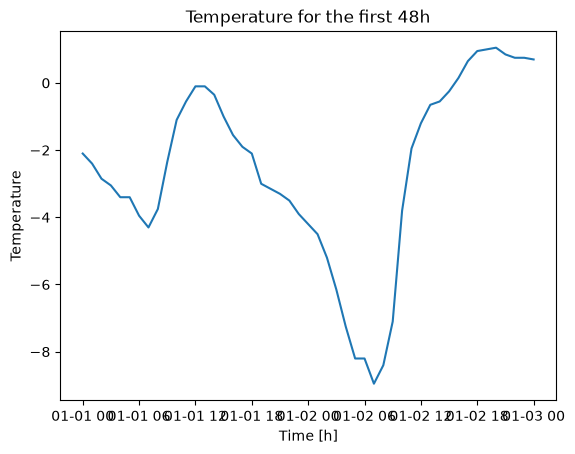

In [92]:
plt.plot(data["temperature"][:49])
plt.xlabel("Time [h]")
plt.ylabel("Temperature")
plt.title("Temperature for the first 48h")
plt.show()

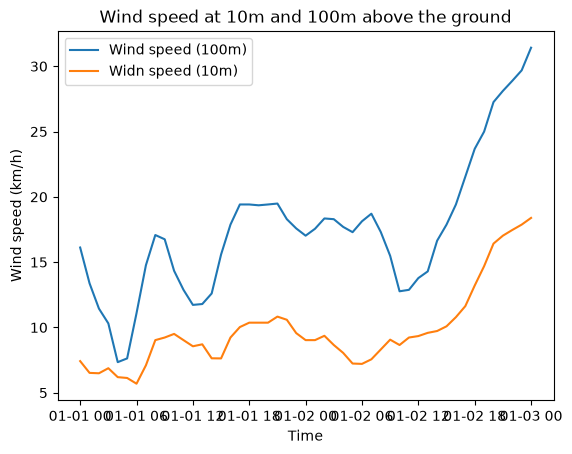

In [93]:
plt.plot(data["wind_speed_100m"][:49], label="Wind speed (100m)")
plt.plot(data["wind_speed_10m"][:49], label="Widn speed (10m)")
plt.title("Wind speed at 10m and 100m above the ground")
plt.xlabel("Time")
plt.ylabel("Wind speed (km/h)")
plt.legend()
plt.show()

# Initialization of the Neural Network
For this task I will use convolution to extract the features from data and LSTM to preserve time information. 

First we need to normalize the data, since almost each feature has a different scale. For that I will use `Z-score` normalization.

In [101]:
for feature in data:
    mean = np.mean(data[feature])
    std_dev = np.std(data[feature])
    z_score = (data[feature] - mean) / std_dev
    data[feature] = z_score
   
data.describe()
    

,temperature,rain,precipitation,relative_humidity,dew_point,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m
count,2.315760e+05,2.315760e+05,2.315760e+05,2.315760e+05,2.315760e+05,2.315760e+05,2.315760e+05,2.315760e+05,2.315760e+05
mean,6.325542e-09,-1.172861e-08,-3.689899e-09,-6.325542e-09,2.108514e-09,4.217028e-09,-2.108514e-09,-4.744157e-09,-5.271285e-09
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-4.400406e+00,-2.220179e-01,-2.396647e-01,-3.406735e+00,-5.090693e+00,-2.096247e+00,-2.264199e+00,-2.153381e+00,-2.158290e+00
25%,-7.660691e-01,-2.220179e-01,-2.396647e-01,-6.836951e-01,-6.692986e-01,-7.492997e-01,-6.949839e-01,-7.980771e-01,-7.995762e-01
50%,-1.198679e-02,-2.220179e-01,-2.396647e-01,2.163547e-01,4.917793e-02,-1.375940e-01,-5.730472e-02,1.718746e-01,1.951712e-01
75%,7.647748e-01,-2.220179e-01,-2.396647e-01,8.384116e-01,7.607460e-01,5.774247e-01,5.967801e-01,8.025218e-01,8.026946e-01
max,3.038361e+00,6.810575e+01,6.665292e+01,1.462544e+00,2.453311e+00,8.126969e+00,7.660718e+00,1.705664e+00,1.667016e+00


We can see that the data was correctly normalized using `Z-scores`. However, looking at `rain` and `percipitation`. The `min`, `25%` and `75%` values are the same, showing that the data is highly skewed. For now we will ignore this, but if needed we will come back to this in the later part. 

In [ ]:
class ConvLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=9, out_channels=32, kernel_size=4, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.lstm = nn.LSTM(
            input_size=64, hidden_size=64, num_layers=2, batch_first=True
        )
        self.linear = nn.Linear(64, 1)